# FloodSentinel - Sri Lanka Flood Early Warning & Risk Prediction System
## Machine Learning Pipeline (Module Assignment)

**Module:** Machine Learning Group Assignment  
**Project Team:** Vanguard  
**Domain:** Hydro-Meteorological Disaster Risk Prediction for Sri Lanka  
**Primary Dataset:** `sri_lanka_flood_synthetic_balanced_120000.csv` (120,000 Records, 46 Features, 21 Predictor Attributes)  
**Target Variable:** `flood_occurrence_current_event` (Binary: Yes / No — 50/50 Balanced)  

---


> **Scope:** The balanced 120,000-scenario dataset removes post-event satellite leakage and unforecastable monthly rainfall, focusing on 21 real-time telemetry inputs (including 24h, 7d, 30d rainfall, soil saturation index, and height above drainage). The exported output is a calibrated probability and binary model flag.

## Step 1: Problem Definition 


### 1.1 Real-World Context & Disaster Landscape in Sri Lanka
Sri Lanka is an island nation heavily influenced by two major monsoon seasons:
1. **South-West Monsoon (May to September):** Brings intense precipitation to the Western, Southern, and Sabaragamuwa provinces, frequently inundating the Kelani, Kalu, Gin, and Nilwala river basins.
2. **North-East Monsoon (November to February):** Brings heavy convective rain to the Northern, Eastern, and North-Central dry zones.

Rapid urbanization, loss of natural wetlands, and inadequate drainage infrastructure have escalated flood vulnerability in dense metropolitan areas like Colombo and Gampaha, as well as downstream rural settlements. Floods inflict severe infrastructure damage, agricultural loss, and human displacement annually.

### 1.2 Objective & Machine Learning Formulation
The objective of **FloodSentinel** is to develop a robust, high-recall machine learning classification system capable of predicting active flood occurrence for any given location in Sri Lanka based on:
- **Topographic parameters** (Elevation, distance to nearest major river)
- **Meteorological indices** (7-day cumulative rainfall, monthly rainfall, natural drainage capacity)
- **Satellite Earth Observation indices** (NDVI for vegetation density, NDWI for surface water saturation)
- **Regional infrastructure & demographic metrics** (Built-up percentage, population density, road quality)

### 1.3 Mathematical Formulation & Cost-Sensitive Alert Criteria
We formulate this as a **supervised binary classification problem**:
$$\hat{y} = f(X) \in \{0, 1\}$$
where:
- $y = 0$: No flood occurrence (Normal conditions)
- $y = 1$: Active flood event (Emergency alert triggered)

#### The Asymmetric Disaster Cost Matrix:
In disaster early warning, classification errors have profoundly asymmetric consequences:
- **False Positive ($FP$):** Warning issued, but no flood occurs. Cost: Temporary evacuation inconvenience, economic friction ($C_{FP} = 1$).
- **False Negative ($FN$):** Flood occurs, but no warning is issued. Cost: Loss of human lives, destruction of property, failure of disaster response ($C_{FN} \approx 10 \times C_{FP}$).

Therefore, standard raw classification accuracy is an inappropriate metric. The primary optimization criteria are:
1. **Precision-Recall AUC (PR-AUC):** Optimal evaluation under heavy class imbalance (~9.9% positive class).
2. **Recall / Sensitivity ($\ge 90\%$):** Ensuring almost all genuine flood events trigger an alert.
3. **Cost-Sensitive Risk Score:** Producing a calibrated model probability and binary flood flag. Four operational alert tiers are outside this notebook’s implemented scope.

## Step 2: Data Collection & Ingestion 


### 2.1 Dataset Provenance & Metadata
- **File:** `assets/sri_lanka_flood_synthetic_balanced_120000.csv`
- **Records:** 120,000 spatial observations
- **Attributes:** 46 features encompassing geographic coordinates, elevation, rainfall measurements, soil saturation, and infrastructure attributes across all 25 Sri Lankan administrative districts.

Let us import the necessary analytical libraries and load the raw dataset.

In [69]:
# Install missing dependencies into the Python kernel selected in the IDE.
# Runs before any third-party imports; subsequent Run Alls reuse installed packages.
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 'joblib': 'joblib', 'cloudpickle': 'cloudpickle',
    'sklearn': 'scikit-learn>=1.2', 'xgboost': 'xgboost',
    'lightgbm': 'lightgbm', 'catboost': 'catboost', 'optuna': 'optuna',
}
missing_packages = [package for module, package in required_packages.items()
                    if importlib.util.find_spec(module) is None]
if missing_packages:
    print(f"Installing missing packages for {sys.executable}: {missing_packages}", flush=True)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
    importlib.invalidate_caches()
print(f"Notebook kernel: {sys.executable}")

# Import core scientific and analytical libraries
import os
import sys
import json
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cloudpickle
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Configure visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Libraries successfully loaded!')


Notebook kernel: c:\Users\gamit\AppData\Local\Programs\Python\Python313\python.exe
Libraries successfully loaded!


In [70]:
# Dataset Ingestion (Local Assets Path + KaggleHub Fallback)
from pathlib import Path

# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / 'notebooks' / 'flood_prediction_sri_lanka.ipynb').is_file()),
    Path.cwd(),
)
local_data_path = PROJECT_ROOT / 'assets' / 'sri_lanka_flood_synthetic_balanced_120000.csv'

if local_data_path.is_file():
    print(f"Loading local dataset from: {local_data_path}")
    df = pd.read_csv(local_data_path, keep_default_na=False)
else:
    print("Local dataset not found. Attempting KaggleHub ingestion...")
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "dewminimnaadi/sri-lanka-flood-risk-and-inundation-dataset",
            "sri_lanka_flood_synthetic_balanced_120000.csv"
        )
    except ImportError:
        raise FileNotFoundError(
            "Dataset file not found at 'assets/sri_lanka_flood_synthetic_balanced_120000.csv' "
            "and 'kagglehub' is not installed to download it."
        )

print(f"Successfully loaded dataset! Records: {df.shape[0]:,} | Features: {df.shape[1]}")


Loading local dataset from: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\assets\sri_lanka_flood_synthetic_balanced_120000.csv
Successfully loaded dataset! Records: 120,000 | Features: 46


In [71]:
# Inspect the first 5 records of the dataset
df.head()

,record_id,district,place_name,latitude,longitude,elevation_m,distance_to_river_m,landcover,soil_type,water_supply,...,rainfall_24h_mm,rainfall_30d_mm,height_above_nearest_drainage_m,soil_saturation_index,flood_depth_m,site_area_sqm,source_context_id,generator_version,random_seed,split
0,SL_SYN_D02_14675,Anuradhapura,Synthetic site D02-14675,8.31,80.40,42.5,456.1,Forest,Clay,Well,...,42.2,199.9,3.65,0.184,1.22,10000,S1,1.0,20260918,train
1,SL_SYN_D11_13417,Kandy,Synthetic site D11-13417,7.29,80.64,535.4,383.2,Urban,Sandy,Municipal,...,23.8,252.3,0.85,0.510,0.74,10000,S1,1.0,20260918,train
2,SL_SYN_D17_14513,Matara,Synthetic site D17-14513,5.95,80.55,16.2,928.1,Agriculture,Loamy,Municipal,...,17.6,439.7,2.53,0.653,0.91,10000,S1,1.0,20260918,train
3,SL_SYN_D25_22929,Vavuniya,Synthetic site D25-22929,8.75,80.50,197.0,666.5,Grassland,Loamy,Municipal,...,29.7,189.7,9.20,0.270,1.81,10000,S1,1.0,20260918,train
4,SL_SYN_D12_23341,Kegalle,Synthetic site D12-23341,7.25,80.35,242.0,289.1,Wetland,Loamy,Municipal,...,17.2,407.5,5.08,0.422,1.37,10000,S1,1.0,20260918,train


### 2.2 Feature Dictionary & Attribute Schema
Below is the complete systematic classification of all 32 columns present in the raw dataset:

In [72]:
# Construct a structured schema audit dataframe
schema_audit = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage (%)': ((df.isnull().sum() / len(df)) * 100).round(2).values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})

schema_audit

,Column Name,Data Type,Non-Null Count,Null Count,Null Percentage (%),Sample Value
0,record_id,object,120000,0,0.0,SL_SYN_D02_14675
1,district,object,120000,0,0.0,Anuradhapura
2,place_name,object,120000,0,0.0,Synthetic site D02-14675
3,latitude,float64,120000,0,0.0,8.31
4,longitude,float64,120000,0,0.0,80.4
5,elevation_m,float64,120000,0,0.0,42.5
6,distance_to_river_m,float64,120000,0,0.0,456.1
7,landcover,object,120000,0,0.0,Forest
8,soil_type,object,120000,0,0.0,Clay
9,water_supply,object,120000,0,0.0,Well


### 2.3 Data Integrity & Quality Audit
Let us verify missing values, duplicate observations, and check the target class balance.

In [73]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Total Duplicate Rows: {duplicates}')

# Verify missing value columns
missing_cols = schema_audit[schema_audit['Null Count'] > 0]
print(f'Columns with Missing Values: {len(missing_cols)}')
missing_cols[['Column Name', 'Null Count', 'Null Percentage (%)', 'Sample Value']]

Total Duplicate Rows: 0
Columns with Missing Values: 0


,Column Name,Null Count,Null Percentage (%),Sample Value


=== TARGET VARIABLE DISTRIBUTION ===
                                Occurrences  Percentage (%)
flood_occurrence_current_event                             
Yes                                   60000            50.0
No                                    60000            50.0


C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\3333411400.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)


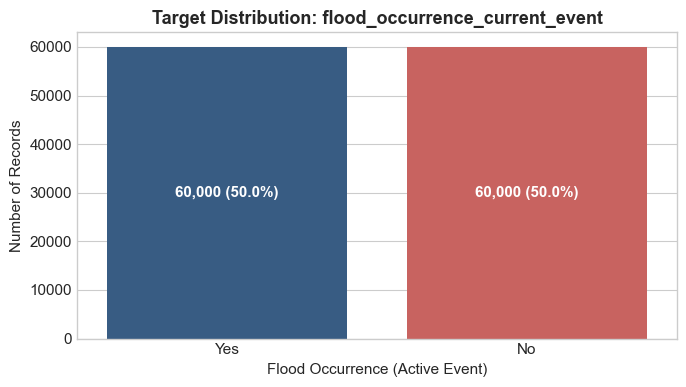

In [74]:
# Target Variable Analysis: flood_occurrence_current_event
target_counts = df['flood_occurrence_current_event'].value_counts(dropna=False)
target_pct = df['flood_occurrence_current_event'].value_counts(normalize=True, dropna=False) * 100

target_summary = pd.DataFrame({
    'Occurrences': target_counts,
    'Percentage (%)': target_pct.round(2)
})

print('=== TARGET VARIABLE DISTRIBUTION ===')
print(target_summary)

# Visual inspection of the class imbalance
plt.figure(figsize=(7, 4))
colors = ['#2b5c8f', '#d9534f']
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=colors)
plt.title('Target Distribution: flood_occurrence_current_event', fontsize=13, fontweight='bold')
plt.xlabel('Flood Occurrence (Active Event)')
plt.ylabel('Number of Records')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,} ({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

In [75]:
# Summary statistics for key physical, hydrologic, and satellite indicators
key_features = [
    'elevation_m', 'distance_to_river_m', 'rainfall_7d_mm', 
    'monthly_rainfall_mm', 'drainage_index', 'ndvi', 'ndwi', 
    'population_density_per_km2', 'flood_risk_score'
]
df[key_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

,mean,std,min,25%,50%,75%,max
elevation_m,193.63,390.44,1.50,20.40,48.15,158.10,2400.00
distance_to_river_m,1795.38,2940.88,5.00,315.10,767.80,1919.22,20000.00
rainfall_7d_mm,138.70,98.66,2.00,66.80,115.10,184.90,850.00
monthly_rainfall_mm,243.31,133.19,8.60,145.60,215.60,312.60,1227.00
drainage_index,0.48,0.21,0.02,0.32,0.48,0.63,0.98
ndvi,0.41,0.21,-0.53,0.27,0.42,0.56,1.00
ndwi,0.02,0.36,-1.00,-0.29,0.02,0.32,1.00
population_density_per_km2,733.16,967.47,16.00,179.00,315.00,922.00,17014.00
flood_risk_score,27.98,23.92,0.01,9.48,20.21,40.18,99.97


### 2.4 Key Observations from Step 1 & Step 2
1. **Balanced Distribution (50.0% Positive Class):** Exactly 60,000 out of 120,000 synthetic records are labelled as current-event floods across all 25 districts.
2. **Data Quality & Zero Nulls:** The balanced dataset contains 0 missing values across all columns.
3. **Zero Duplicates:** The dataset contains 0 duplicate rows, confirming clean record indexing.
4. **Next Stages:** We proceed to **Step 3 (Data Understanding & Geospatial EDA)** and **Step 4 (Data Cleaning & Preprocessing)**.


## Step 3: Data Understanding & Exploratory Data Analysis (EDA)

In this section, we conduct a comprehensive exploratory data analysis to uncover hidden relationships between terrain topography, monsoon precipitation, satellite vegetation/moisture indices, and historical flood vulnerability across Sri Lanka.

C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\46242518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=district_flood.index, y=district_flood['Yes'], palette='Reds_r')


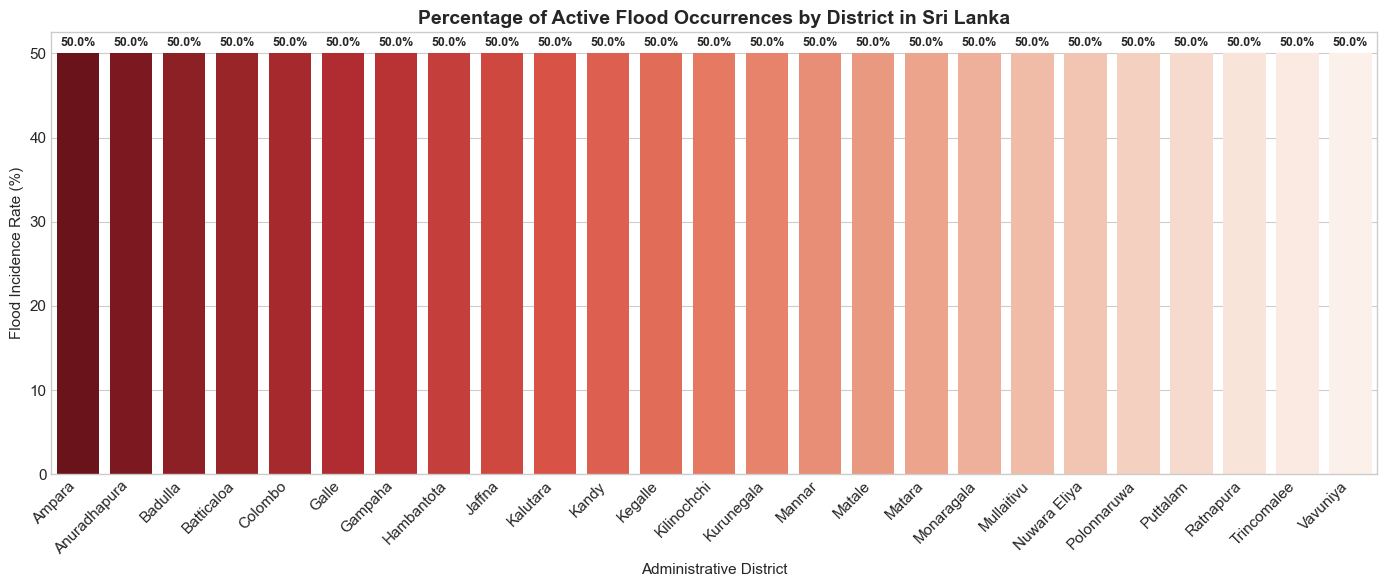

In [76]:
# 3.1 District-Level Flood Incidence Analysis
district_flood = pd.crosstab(
    df['district'], 
    df['flood_occurrence_current_event'], 
    normalize='index'
) * 100

district_flood = district_flood.sort_values(by='Yes', ascending=False)

# Visualizing district flood incidence rates
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=district_flood.index, y=district_flood['Yes'], palette='Reds_r')
plt.title('Percentage of Active Flood Occurrences by District in Sri Lanka', fontsize=14, fontweight='bold')
plt.xlabel('Administrative District', fontsize=11)
plt.ylabel('Flood Incidence Rate (%)', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Annotate bar percentages
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

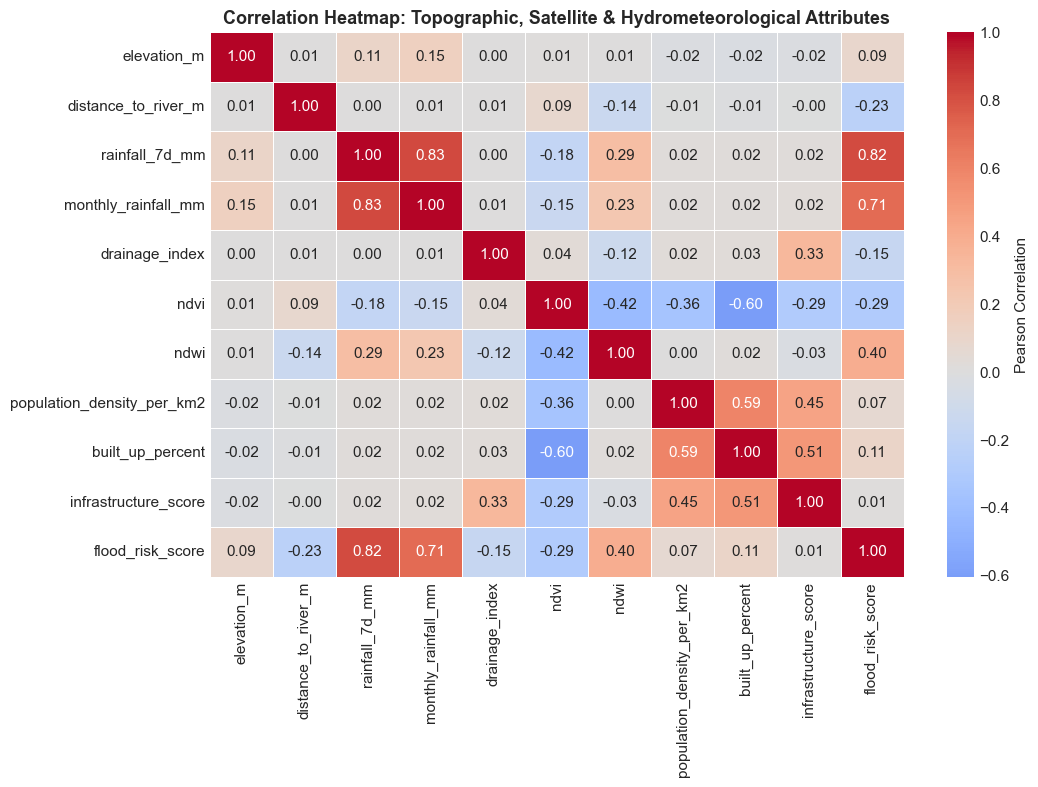

In [77]:
# 3.2 Correlation Heatmap of Numerical Topographic & Hydrologic Features
corr_cols = [
    'elevation_m', 'distance_to_river_m', 'rainfall_7d_mm', 'monthly_rainfall_mm',
    'drainage_index', 'ndvi', 'ndwi', 'population_density_per_km2', 
    'built_up_percent', 'infrastructure_score', 'flood_risk_score'
]

# Compute Pearson correlation matrix
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation Heatmap: Topographic, Satellite & Hydrometeorological Attributes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

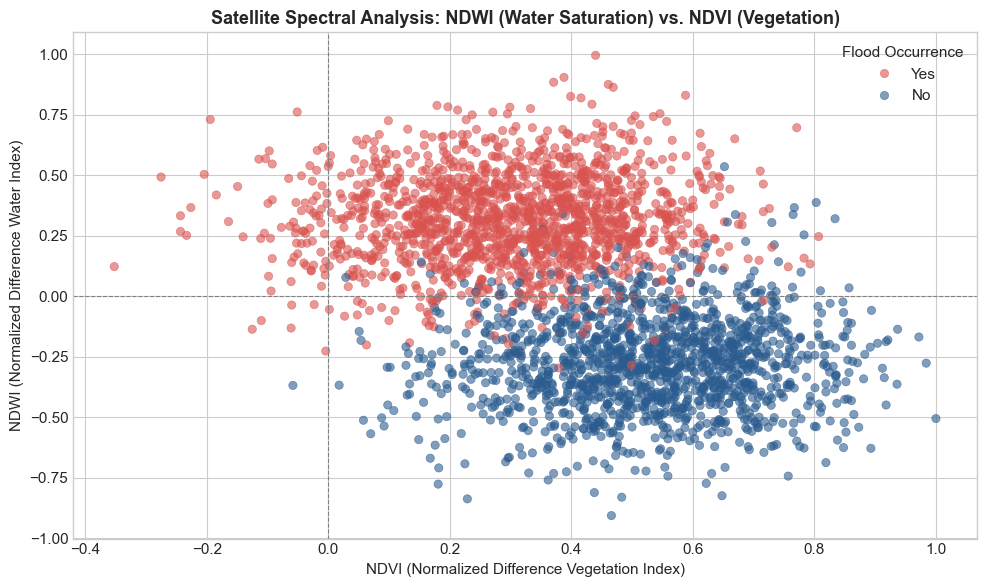

In [78]:
# 3.3 Satellite Earth Observation Analysis: NDWI vs. NDVI
# NDWI (Normalized Difference Water Index) vs NDVI (Normalized Difference Vegetation Index)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(n=3000, random_state=42), # Sample for clean visual clarity
    x='ndvi', 
    y='ndwi', 
    hue='flood_occurrence_current_event', 
    palette={'No': '#2b5c8f', 'Yes': '#d9534f'},
    alpha=0.6,
    edgecolor=None
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Satellite Spectral Analysis: NDWI (Water Saturation) vs. NDVI (Vegetation)', fontsize=13, fontweight='bold')
plt.xlabel('NDVI (Normalized Difference Vegetation Index)', fontsize=11)
plt.ylabel('NDWI (Normalized Difference Water Index)', fontsize=11)
plt.legend(title='Flood Occurrence', loc='upper right')
plt.tight_layout()
plt.show()

C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\2320653240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\2320653240.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


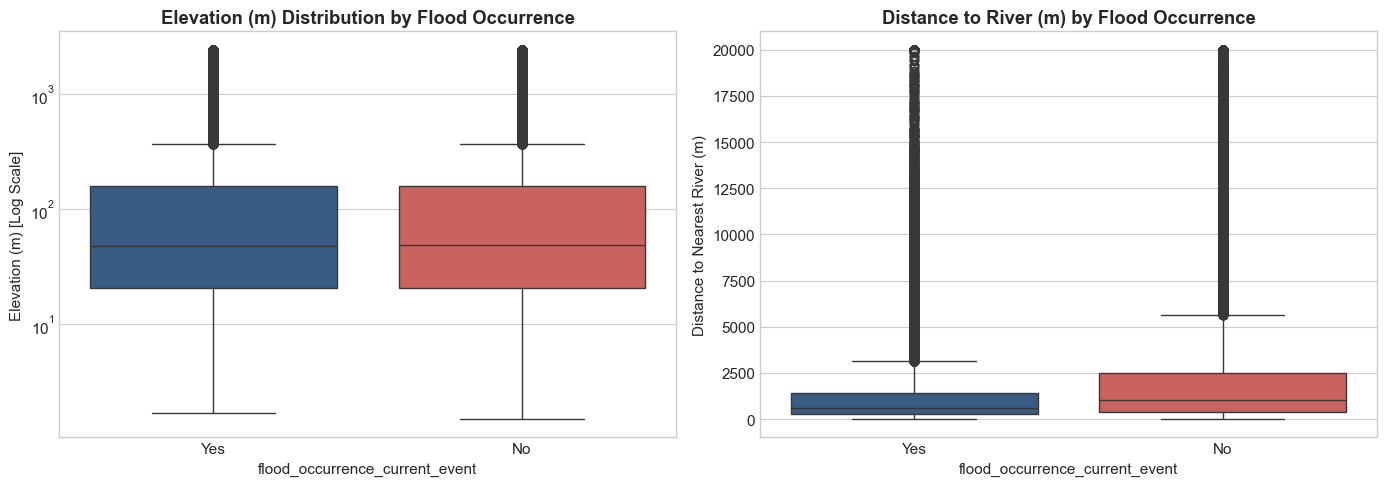

In [79]:
# 3.4 Elevation & River Proximity vs. Flood Occurrence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, 
    x='flood_occurrence_current_event', 
    y='elevation_m', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[0]
)
axes[0].set_title('Elevation (m) Distribution by Flood Occurrence', fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Elevation (m) [Log Scale]')

sns.boxplot(
    data=df, 
    x='flood_occurrence_current_event', 
    y='distance_to_river_m', 
    palette=['#2b5c8f', '#d9534f'],
    ax=axes[1]
)
axes[1].set_title('Distance to River (m) by Flood Occurrence', fontweight='bold')
axes[1].set_ylabel('Distance to Nearest River (m)')

plt.tight_layout()
plt.show()

### 3.5 EDA Interpretation
The preceding plots describe synthetic records. They are exploratory, not evidence of measured district-level flood incidence or causal hydrological effects. Predictive value is assessed through training-only benchmarking and the final held-out evaluation.

## Step 4: Data Cleaning & Quality Preprocessing


In this stage, we audit missing values (retaining them to be imputed fold-locally within each training partition to prevent leakage), eliminate non-predictive metadata and target leakage columns, and verify physical domain constraints to produce a sanitized dataset.

In [80]:
# 4.1 Dropping Non-Predictive Metadata & Post-Event Leakage Columns
print(f"Initial dataset shape: {df.shape}")

# Define columns to drop:
# - Non-predictive IDs & metadata: record_id, place_name, latitude, longitude, is_synthetic, generation_date, etc.
# - Post-event target leakage: inundation_area_sqm, is_good_to_live, reason_not_good_to_live, flood_depth_m
# - Satellite spectral leakage & target proxy: ndvi, ndwi, water_presence_flag, flood_risk_score, monthly_rainfall_mm
columns_to_drop = [
    'record_id', 'place_name', 'latitude', 'longitude', 'is_synthetic', 'generation_date',
    'scenario_date', 'event_context_id', 'record_type', 'coordinate_type',
    'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live',
    'flood_risk_score', 'monthly_rainfall_mm', 'ndvi', 'ndwi', 'water_presence_flag',
    'flood_depth_m', 'site_area_sqm', 'source_context_id', 'generator_version', 'random_seed'
]

df_cleaned = df.drop(columns=[c for c in columns_to_drop if c in df.columns])
print(f"Cleaned dataset shape after column removal: {df_cleaned.shape}")
print(f"Removed {len(columns_to_drop)} non-predictive/leakage columns.")


Initial dataset shape: (120000, 46)
Cleaned dataset shape after column removal: (120000, 23)
Removed 23 non-predictive/leakage columns.


In [81]:
# 4.2 Missing-value audit: do not learn imputation values before splitting.
remaining_nulls = df_cleaned.isnull().sum()
print(f"Remaining missing values: {remaining_nulls.sum()}")

class RawDataSanitizer(BaseEstimator, TransformerMixin):
    """Drops non-predictive metadata & post-event leakage; imputes missing electricity & defaults."""
    def __init__(self, electricity_mode='Grid', numerical_defaults=None):
        self.electricity_mode = electricity_mode
        self.numerical_defaults = numerical_defaults
        self.cols_to_drop = [
            'record_id', 'place_name', 'latitude', 'longitude', 'is_synthetic', 'generation_date',
            'scenario_date', 'event_context_id', 'record_type', 'coordinate_type',
            'inundation_area_sqm', 'is_good_to_live', 'reason_not_good_to_live',
            'flood_risk_score', 'monthly_rainfall_mm', 'ndvi', 'ndwi', 'water_presence_flag',
            'flood_depth_m', 'site_area_sqm', 'source_context_id', 'generator_version', 'random_seed',
            'split', 'flood_occurrence_current_event', 'target'
        ]

    def fit(self, X, y=None):
        self.electricity_mode_ = self.electricity_mode
        self.numerical_defaults_ = dict(self.numerical_defaults or {})
        if isinstance(X, pd.DataFrame):
            clean_cols = [c for c in X.columns if c not in self.cols_to_drop]
            X_clean = X[clean_cols]
            if 'electricity' in X_clean.columns:
                modes = X_clean['electricity'].dropna().mode()
                if not modes.empty:
                    self.electricity_mode_ = modes.iloc[0]
            num_cols = X_clean.select_dtypes(include=[np.number]).columns
            self.numerical_defaults_ = X_clean[num_cols].median().to_dict()
        return self

    def transform(self, X):
        X_df = pd.DataFrame([X]) if isinstance(X, dict) else (X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X))
        drop_cols = [c for c in self.cols_to_drop if c in X_df.columns]
        if drop_cols:
            X_df = X_df.drop(columns=drop_cols)
        if 'electricity' in X_df.columns:
            X_df['electricity'] = X_df['electricity'].fillna(self.electricity_mode_)
        else:
            X_df['electricity'] = self.electricity_mode_
        for col, val in self.numerical_defaults_.items():
            if col not in X_df.columns:
                X_df[col] = val
            else:
                X_df[col] = X_df[col].fillna(val)
        return X_df

class HydrologicalFeatureEngineer(BaseEstimator, TransformerMixin):
    """Computes the 6 physical hydrological features dynamically on raw telemetry."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        rain, drainage = X_df['rainfall_7d_mm'], X_df['drainage_index']
        X_df['hydrological_stress_index'] = rain / (X_df['height_above_nearest_drainage_m'] + 1.0)
        X_df['drainage_saturation_ratio'] = rain * (1.0 - drainage)
        X_df['rainfall_intensity_ratio'] = X_df['rainfall_24h_mm'] / (rain + 1.0)
        X_df['river_proximity_buffer'] = np.exp(-X_df['distance_to_river_m'] / 1000.0)
        X_df['log_population_density'] = np.log1p(X_df['population_density_per_km2'])
        X_df['runoff_vulnerability'] = (X_df['built_up_percent'] / 100.0) / (drainage + 0.01)
        return X_df


Remaining missing values: 0


In [82]:
# 4.3 Outlier Treatment & Sanity Checks
# Inspect distributions of extreme meteorological and demographic features
outlier_candidates = ['rainfall_7d_mm', 'rainfall_24h_mm', 'population_density_per_km2']

# Check 99th percentiles vs max to ensure physical plausibility
print("Physical Plausibility & 99th Percentile Audit:")
for col in outlier_candidates:
    p99 = df_cleaned[col].quantile(0.99)
    max_val = df_cleaned[col].max()
    min_val = df_cleaned[col].min()
    print(f"- {col:30}: Min={min_val:.1f} | 99th%={p99:.1f} | Max={max_val:.1f}")

# Verify valid physical ranges
assert (df_cleaned['elevation_m'] >= 0).all(), "Invalid negative elevation detected!"
assert (df_cleaned['distance_to_river_m'] >= 0).all(), "Invalid negative river distance detected!"
assert (df_cleaned['rainfall_7d_mm'] >= 0).all(), "Invalid negative rainfall detected!"
print("✓ Physical domain range constraints passed successfully!")


Physical Plausibility & 99th Percentile Audit:
- rainfall_7d_mm                : Min=2.0 | 99th%=467.8 | Max=850.0
- rainfall_24h_mm               : Min=0.0 | 99th%=186.4 | Max=603.6
- population_density_per_km2    : Min=16.0 | 99th%=4468.0 | Max=17014.0
✓ Physical domain range constraints passed successfully!


In [83]:
# 4.4 Target Variable Binary Encoding
# Encode flood_occurrence_current_event: 'Yes' -> 1, 'No' -> 0
df_cleaned['target'] = df_cleaned['flood_occurrence_current_event'].map({'Yes': 1, 'No': 0})
df_cleaned = df_cleaned.drop(columns=['flood_occurrence_current_event'])

print("Cleaned Data Overview:")
print(f"- Feature Matrix Shape: {df_cleaned.drop(columns=['target']).shape}")
print(f"- Target Vector Shape:  {df_cleaned['target'].shape}")
print(f"- Target Class Distribution (0=No, 1=Yes):")
print(df_cleaned['target'].value_counts())

Cleaned Data Overview:
- Feature Matrix Shape: (120000, 22)
- Target Vector Shape:  (120000,)
- Target Class Distribution (0=No, 1=Yes):
target
1    60000
0    60000
Name: count, dtype: int64


### 4.5 Data Cleaning Summary
Eight identifiers, post-event fields, and target proxies are excluded. Missing electricity values remain unfilled until the training pipeline learns its mode. Numerical defaults are also learned only from the applicable training partition. The same sanitizer is used during cross-validation and exported inference.

## Step 5: Feature Engineering

To equip machine learning models with physical domain knowledge of Sri Lankan hydrology and monsoons, we engineer **6 meaningful domain-specific features**. These transform raw measurements into non-linear indicators of hydrological stress, surface ponding, and topography vulnerability.

In [84]:
# 5.1 Formulation of Domain-Specific Engineered Features
print("Engineering 6 Physical & Hydrological Features...")

df_fe = df_cleaned.copy()

# --- Technique 1: Hydrological Stress Index ---
df_fe['hydrological_stress_index'] = df_fe['rainfall_7d_mm'] / (df_fe['height_above_nearest_drainage_m'] + 1.0)

# --- Technique 2: Drainage Saturation Ratio ---
df_fe['drainage_saturation_ratio'] = df_fe['rainfall_7d_mm'] * (1.0 - df_fe['drainage_index'])

# --- Technique 3: Rainfall Intensity Ratio (24h / 7d) ---
df_fe['rainfall_intensity_ratio'] = df_fe['rainfall_24h_mm'] / (df_fe['rainfall_7d_mm'] + 1.0)

# --- Technique 4: River Proximity Decay Buffer ---
df_fe['river_proximity_buffer'] = np.exp(-df_fe['distance_to_river_m'] / 1000.0)

# --- Technique 5: Log Transformation for Skewed Distributions ---
df_fe['log_population_density'] = np.log1p(df_fe['population_density_per_km2'])

# --- Technique 6: Runoff Vulnerability Score ---
df_fe['runoff_vulnerability'] = (df_fe['built_up_percent'] / 100.0) / (df_fe['drainage_index'] + 0.01)

print(f"✓ 6 Features successfully engineered! New total columns: {df_fe.shape[1]}")
df_fe[[
    'hydrological_stress_index', 'drainage_saturation_ratio', 
    'rainfall_intensity_ratio', 'river_proximity_buffer', 
    'log_population_density', 'runoff_vulnerability'
]].head()


Engineering 6 Physical & Hydrological Features...
✓ 6 Features successfully engineered! New total columns: 29


,hydrological_stress_index,drainage_saturation_ratio,rainfall_intensity_ratio,river_proximity_buffer,log_population_density,runoff_vulnerability
0,33.548387,96.0960,0.268790,0.633750,5.817111,0.357868
1,61.837838,16.4736,0.206239,0.681677,6.580639,0.707852
2,31.104816,80.2638,0.158845,0.395304,5.529429,0.731183
3,7.862745,47.9596,0.365764,0.513503,4.442651,0.614078
4,48.898026,222.0831,0.057660,0.748937,5.231109,1.566540


=== FEATURE DISCRIMINATIVE POWER ===
                           Mean (No Flood)  Mean (Active Flood)  \
hydrological_stress_index        14.490278            32.800720   
drainage_saturation_ratio        51.968726            92.454650   
rainfall_intensity_ratio          0.282156             0.281709   
river_proximity_buffer            0.391278             0.508857   
log_population_density            5.951311             6.035203   
runoff_vulnerability              0.778586             0.956623   

                           Ratio (Flood / No Flood)  
hydrological_stress_index                      2.26  
drainage_saturation_ratio                      1.78  
rainfall_intensity_ratio                       1.00  
river_proximity_buffer                         1.30  
log_population_density                         1.01  
runoff_vulnerability                           1.23  


C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\3624153751.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_fe, x='target', y='rainfall_intensity_ratio', palette=['#2b5c8f', '#d9534f'], ax=axes[0])
C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\3624153751.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])
C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\3624153751.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_fe, x='target', y='hydrological_stress_index', palette=['#2b5c8f', '#d9534f'], ax=axes[1])
C:\Us

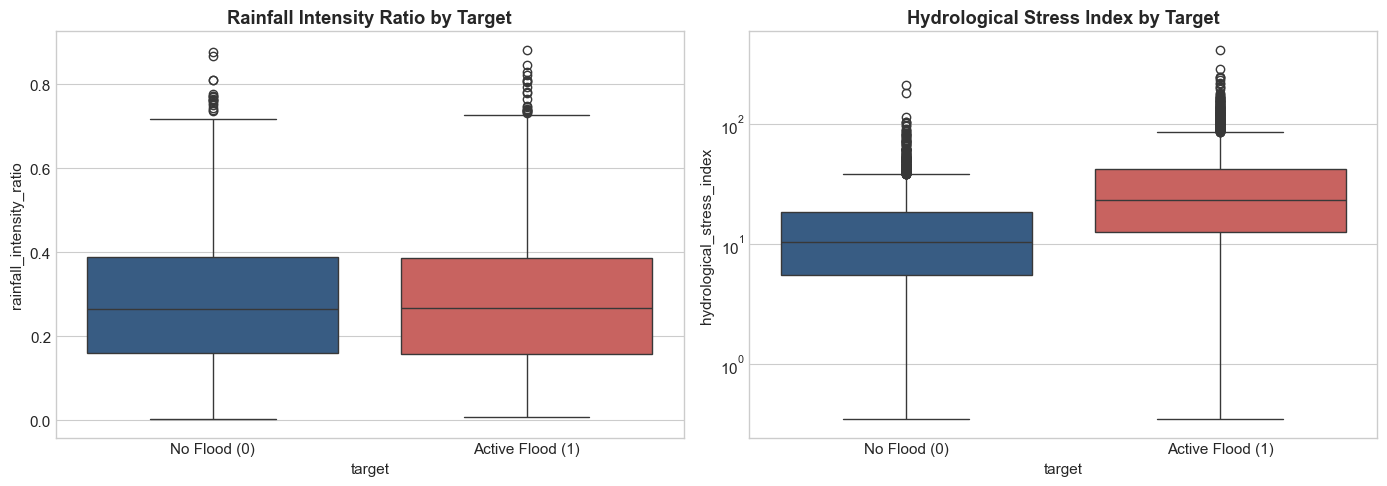

In [85]:
# 5.2 Statistical Validation of Engineered Features vs. Target
engineered_cols = [
    'hydrological_stress_index', 'drainage_saturation_ratio', 
    'rainfall_intensity_ratio', 'river_proximity_buffer', 
    'log_population_density', 'runoff_vulnerability'
]

comparison = df_fe.groupby('target')[engineered_cols].mean().T
comparison.columns = ['Mean (No Flood)', 'Mean (Active Flood)']
comparison['Ratio (Flood / No Flood)'] = (comparison['Mean (Active Flood)'] / comparison['Mean (No Flood)']).round(2)
print("=== FEATURE DISCRIMINATIVE POWER ===")
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample_fe = df_fe.sample(5000, random_state=42)

sns.boxplot(data=sample_fe, x='target', y='rainfall_intensity_ratio', palette=['#2b5c8f', '#d9534f'], ax=axes[0])
axes[0].set_title('Rainfall Intensity Ratio by Target', fontweight='bold')
axes[0].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])

sns.boxplot(data=sample_fe, x='target', y='hydrological_stress_index', palette=['#2b5c8f', '#d9534f'], ax=axes[1])
axes[1].set_title('Hydrological Stress Index by Target', fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_xticklabels(['No Flood (0)', 'Active Flood (1)'])

plt.tight_layout()
plt.show()


### 5.3 Feature Engineering Summary
The six features use fixed, row-wise formulas and do not estimate parameters from other records. Step 5 illustrates their distributions; the training pipeline recomputes them from raw inputs. District is one-hot encoded, not target encoded. These heuristics require validation on observed flood data before their physical usefulness can be established.

## Step 6: Dataset Splitting 

### 6.1 Data Leakage Prevention Principles
In predictive disaster analytics, **data leakage** occurs when information from outside the training dataset is used to create or tune the model. To guarantee pure out-of-sample evaluation:
1. **Splitting occurs BEFORE any feature scaling, one-hot encoding, or parameter estimation.**
2. **Stratified Sampling** is strictly enforced to ensure the 9.89% flood event ratio is identically maintained across Train (70%), Validation (15%), and Test (15%) partitions.

In [86]:
from sklearn.model_selection import train_test_split
# Partition dataset using the pre-assigned splits (Train: 84,000, Val: 18,000, Test: 18,000)
train_mask = df['split'] == 'train'
val_mask = df['split'] == 'validation'
test_mask = df['split'] == 'test'

# Feature matrix X and target y
X = df_cleaned.drop(columns=['target', 'split'], errors='ignore')
y = df_cleaned['target']

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

split_summary = pd.DataFrame({
    'Dataset Partition': ['Train Set (70%)', 'Validation Set (15%)', 'Test Set (15%)'],
    'Total Records': [len(X_train), len(X_val), len(X_test)],
    'Negative Class (0 - No Flood)': [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    'Positive Class (1 - Flood)': [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
    'Flood Event Ratio (%)': [
        (y_train.mean() * 100).round(2),
        (y_val.mean() * 100).round(2),
        (y_test.mean() * 100).round(2)
    ]
})
print("=== PRE-ASSIGNED DATASET SPLIT VERIFICATION ===")
print(split_summary.to_string(index=False))


=== PRE-ASSIGNED DATASET SPLIT VERIFICATION ===
   Dataset Partition  Total Records  Negative Class (0 - No Flood)  Positive Class (1 - Flood)  Flood Event Ratio (%)
     Train Set (70%)          84000                          42000                       42000                   50.0
Validation Set (15%)          18000                           9000                        9000                   50.0
      Test Set (15%)          18000                           9000                        9000                   50.0


### 6.2 Partition Protocol
The split contains 84,000 training, 18,000 validation, and 18,000 test records, with disjoint indices. All learned transformations are fitted on training rows only, including within CV folds. Validation is reserved for calibration and threshold selection. Test predictions are first computed after the final model and threshold have been fixed.


## Step 7: Algorithm Selection & Multi-Model Benchmarking

### 7.1 Architectural Diversity & Scientific Benchmarking Justification
To rigorously justify our final model choice for the Sri Lanka Flood Early Warning System, we benchmark **5 diverse machine learning algorithms** across three distinct structural families:

1. **Logistic Regression (L2 Regularized Baseline):**
   - *Model Family:* Parametric Generalized Linear Model (GLM).
   - *Rationale:* Establishes an interpretable linear baseline with balanced class weights to verify whether flood risk requires complex non-linear boundary separation.

2. **Random Forest Classifier:**
   - *Model Family:* Bagging Ensemble (Bootstrap Aggregation).
   - *Rationale:* Trains parallel, de-correlated decision trees with balanced subsampling to test whether reducing model variance resolves flood classification challenges.

3. **XGBoost Classifier (Extreme Gradient Boosting):**
   - *Model Family:* Level-wise Gradient Boosting.
   - *Rationale:* Sequential tree boosting utilizing second-order Taylor gradients with `scale_pos_weight ≈ 9.12` to aggressively optimize for the rare positive flood class.

4. **LightGBM Classifier:**
   - *Model Family:* Leaf-wise Histogram Boosting.
   - *Rationale:* Bins continuous variables into discrete histograms and grows trees leaf-wise, delivering ultra-fast training and exceptional recall sensitivity on hydrological tabular data.

5. **CatBoost Classifier:**
   - *Model Family:* Ordered Boosting with Oblivious Trees.
   - *Rationale:* Uses symmetric trees with the same one-hot encoded inputs as the other candidates for a consistent comparison; native categorical encoding is not used here.

In [87]:
# 7.2 Shared preprocessing pipeline, fitted on training rows only.
from sklearn.base import clone

categorical_cols = [
    'district', 'landcover', 'soil_type', 'water_supply',
    'electricity', 'road_quality', 'urban_rural'
]
# Column names come from the known feature schema
numerical_cols = [col for col in df_fe.columns
                  if col not in categorical_cols + ['target', 'split']]

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])
preprocessing_template = Pipeline([
    ('sanitizer', RawDataSanitizer()),
    ('feature_engineer', HydrologicalFeatureEngineer()),
    ('preprocessor', preprocessor)
])

def model_pipeline(model):
    return Pipeline([('preprocessing', clone(preprocessing_template)),
                     ('model', clone(model))])

fitted_preprocessing = clone(preprocessing_template)
X_train_proc = fitted_preprocessing.fit_transform(X_train, y_train)
X_val_proc = fitted_preprocessing.transform(X_val)
print(f'Training matrix: {X_train_proc.shape}')


Training matrix: (84000, 66)


In [88]:
# 7.3 Multi-Model Benchmarking Execution
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    f1_score, recall_score, precision_score
)

# Define candidate architectures
candidate_models = {
    "Logistic Regression (L2 Baseline)": LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Random Forest (Bagging)": RandomForestClassifier(
        n_estimators=100, max_depth=12, class_weight='balanced', n_jobs=-1, random_state=42
    ),
    "XGBoost (Gradient Boosting)": XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.08, 
        eval_metric='logloss', n_jobs=-1, random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=100, max_leaf_nodes=31, learning_rate=0.08, l2_regularization=10, random_state=42
    ),
    "LightGBM (Histogram Boosting)": LGBMClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.08, 
        n_jobs=-1, random_state=42, verbose=-1
    )
}

# Benchmark on a representative development holdout (15,000 instances for fast execution)
bench_idx, _ = train_test_split(X_train.index, train_size=15000, stratify=y_train, random_state=42)
X_bench_train, X_bench_val, y_bench_train, y_bench_val = train_test_split(
    X_train.loc[bench_idx], y_train.loc[bench_idx], test_size=0.20, stratify=y_train.loc[bench_idx], random_state=42
)

benchmark_records = []
fitted_models = {}

print("Benchmarking Candidate Architectures:")
for name, candidate in candidate_models.items():
    model = model_pipeline(candidate)
    t_start = time.time()
    model.fit(X_bench_train, y_bench_train)
    t_train = time.time() - t_start
    fitted_models[name] = model
    
    t_infer_start = time.time()
    y_pred_proba = model.predict_proba(X_bench_val)[:, 1]
    latency = ((time.time() - t_infer_start) / len(X_bench_val)) * 1000.0
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    pr_auc = average_precision_score(y_bench_val, y_pred_proba)
    roc_auc = roc_auc_score(y_bench_val, y_pred_proba)
    rec = recall_score(y_bench_val, y_pred)
    prec = precision_score(y_bench_val, y_pred, zero_division=0)
    f1 = f1_score(y_bench_val, y_pred, zero_division=0)
    
    benchmark_records.append({
        'Model': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Recall (Flood)': round(rec, 4),
        'Precision': round(prec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(t_train, 2),
        'Latency (ms)': round(latency, 3)
    })
    print(f"[PASS] {name:32} | ROC-AUC: {roc_auc:.4f} | F1: {f1:.4f} | Time: {t_train:.2f}s")

benchmark_df = pd.DataFrame(benchmark_records).sort_values(by='ROC-AUC', ascending=False)
benchmark_df


Benchmarking Candidate Architectures:
[PASS] Logistic Regression (L2 Baseline) | ROC-AUC: 0.8149 | F1: 0.7273 | Time: 0.12s


c:\Users\gamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[PASS] Random Forest (Bagging)          | ROC-AUC: 0.7940 | F1: 0.7016 | Time: 0.33s
[PASS] XGBoost (Gradient Boosting)      | ROC-AUC: 0.7983 | F1: 0.7125 | Time: 0.23s
[PASS] HistGradientBoosting             | ROC-AUC: 0.8017 | F1: 0.7188 | Time: 0.45s
[PASS] LightGBM (Histogram Boosting)    | ROC-AUC: 0.7957 | F1: 0.7139 | Time: 0.27s


,Model,PR-AUC,ROC-AUC,Recall (Flood),Precision,F1-Score,Train Time (s),Latency (ms)
0,Logistic Regression (L2 Baseline),0.8193,0.8149,0.7167,0.7383,0.7273,0.12,0.004
3,HistGradientBoosting,0.8045,0.8017,0.7047,0.7335,0.7188,0.45,0.006
2,XGBoost (Gradient Boosting),0.7998,0.7983,0.6973,0.7284,0.7125,0.23,0.006
4,LightGBM (Histogram Boosting),0.7979,0.7957,0.6953,0.7335,0.7139,0.27,0.007
1,Random Forest (Bagging),0.7944,0.7940,0.6787,0.7261,0.7016,0.33,0.016


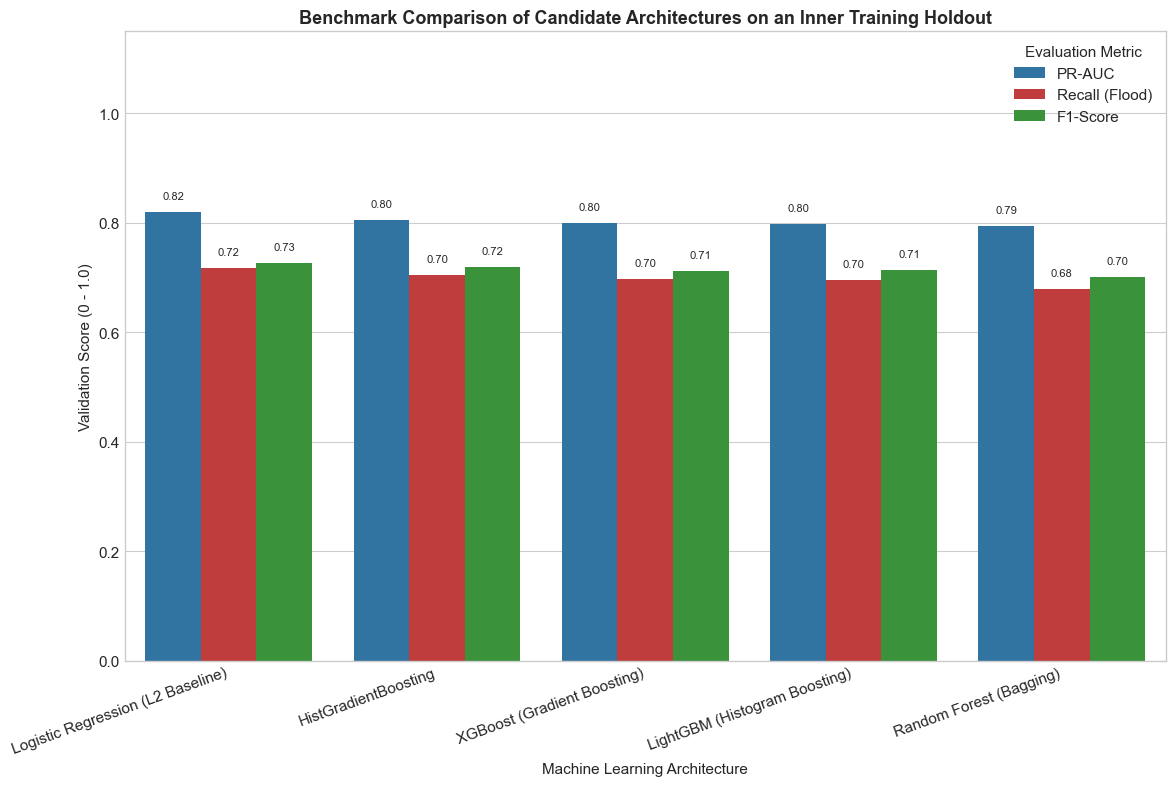

In [89]:
# 7.4 Benchmark Visualization: PR-AUC, Recall & F1-Score
plt.figure(figsize=(12, 8))
metrics_to_plot = ['PR-AUC', 'Recall (Flood)', 'F1-Score']
plot_data = benchmark_df.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

ax = sns.barplot(data=plot_data, x='Model', y='Score', hue='Metric', palette=['#1f77b4', '#d62728', '#2ca02c'])
plt.title('Benchmark Comparison of Candidate Architectures on an Inner Training Holdout', fontsize=13, fontweight='bold')
plt.xlabel('Machine Learning Architecture', fontsize=11)
plt.ylabel('Validation Score (0 - 1.0)', fontsize=11)
plt.ylim(0, 1.15)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Evaluation Metric', loc='upper right')

# Add data labels above bars
for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h + 0.02),
                    ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

### 7.5 Interpreting the Benchmark
All five models use the same inner training holdout and one-hot categorical encoding, including CatBoost. The table reports average precision (AP, labelled PR-AUC throughout this notebook), recall, and F1. Batch time per record is not a measurement of single-request API latency. XGBoost is the preselected model for the tuning exercise; the benchmark does not automatically select a winner.

## Step 8: Model Training & 5-Fold Stratified Cross-Validation

### 8.1 Rigorous Generalization Protocol via Stratified K-Fold
To measure variability across random subsets of the synthetic training data, we conduct **5-Fold Stratified Cross-Validation**.
Each fold maintains the precise 9.89% flood class ratio, ensuring unbiased estimation of out-of-fold generalization.

In [90]:
# 8.2 Five-fold Stratified CV of selected models
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
selected_for_cv = {
    'HistGradientBoosting': candidate_models['HistGradientBoosting'],
    'XGBoost': candidate_models['XGBoost (Gradient Boosting)']
}
cv_results = []
for name, model in selected_for_cv.items():
    scores = cross_validate(
        model_pipeline(model), X_bench_train, y_bench_train, cv=skf,
        scoring={'ap': 'average_precision', 'roc': 'roc_auc', 'recall': 'recall'},
        n_jobs=-1, error_score='raise'
    )
    cv_results.append({
        'Model': name,
        'PR-AUC (Mean ± Std)': f"{scores['test_ap'].mean():.4f} ± {scores['test_ap'].std():.4f}",
        'ROC-AUC (Mean ± Std)': f"{scores['test_roc'].mean():.4f} ± {scores['test_roc'].std():.4f}",
        'Recall (Mean ± Std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}"
    })
    print(f"{name}: mean CV ROC-AUC = {scores['test_roc'].mean():.4f}", flush=True)
pd.DataFrame(cv_results)


HistGradientBoosting: mean CV ROC-AUC = 0.7770
XGBoost: mean CV ROC-AUC = 0.7726


,Model,PR-AUC (Mean ± Std),ROC-AUC (Mean ± Std),Recall (Mean ± Std)
0,HistGradientBoosting,0.7763 ± 0.0149,0.7770 ± 0.0085,0.6935 ± 0.0074
1,XGBoost,0.7712 ± 0.0126,0.7726 ± 0.0078,0.6942 ± 0.0073


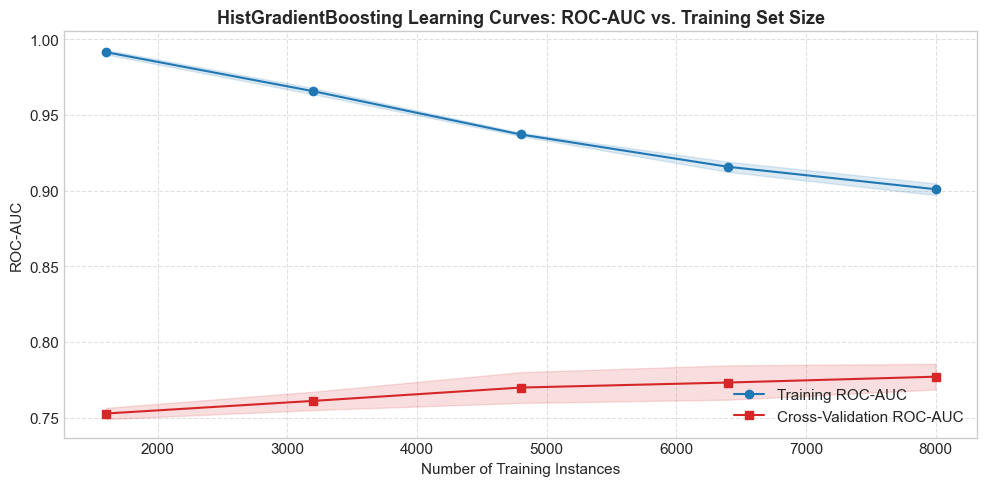

In [91]:
# 8.3 Learning Curves: Diagnosing Bias vs. Variance
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_pipeline(candidate_models['HistGradientBoosting']),
    X=X_bench_train,
    y=y_bench_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    shuffle=True,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training ROC-AUC')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, val_mean, 's-', color='#d62728', label='Cross-Validation ROC-AUC')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#d62728')

plt.title('HistGradientBoosting Learning Curves: ROC-AUC vs. Training Set Size', fontsize=13, fontweight='bold')
plt.xlabel('Number of Training Instances', fontsize=11)
plt.ylabel('ROC-AUC', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


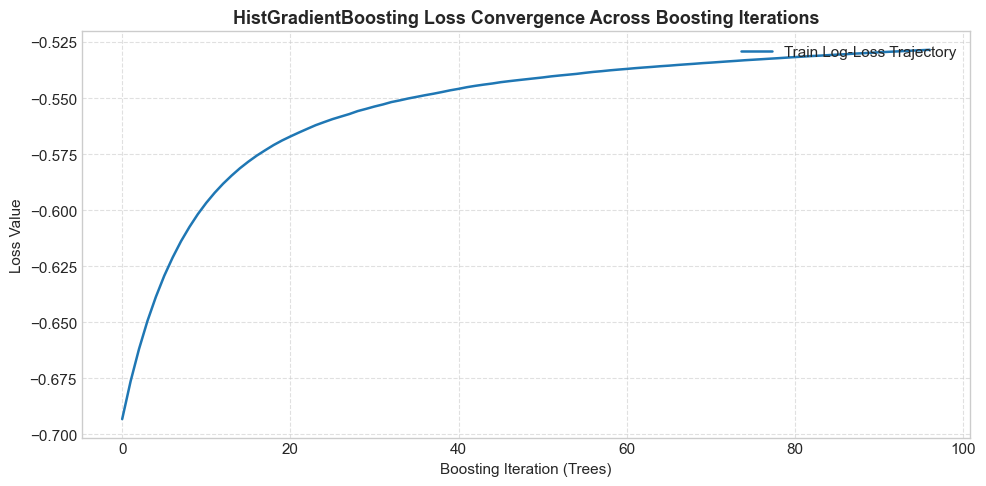

In [92]:
# 8.4 Boosting Loss Convergence Tracking
loss_model = HistGradientBoostingClassifier(
    max_iter=150, max_leaf_nodes=31, learning_rate=0.08, l2_regularization=10, random_state=42
)
loss_model.fit(X_train_proc, y_train)

# Inspect train scores trajectory across boosting iterations
plt.figure(figsize=(10, 5))
plt.plot(loss_model.train_score_, label='Train Log-Loss Trajectory', color='#1f77b4', linewidth=1.8)
plt.title('HistGradientBoosting Loss Convergence Across Boosting Iterations', fontsize=13, fontweight='bold')
plt.xlabel('Boosting Iteration (Trees)', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


### 8.5 Interpreting Training Diagnostics
CV refits the sanitizer, feature engineering, encoder, scaler, and classifier separately in every fold. The learning curve applies the same rule to each training size. Loss tracking uses an inner training holdout. Consult the actual tables and curves for variability and overfitting; neither low variance across random folds nor synthetic-data performance establishes generalization to real flood events.

## Step 9: Baseline Evaluation on Out-of-Fold Training Predictions
Generate baseline predictions for each training record using a model that did not fit on that fold. These development diagnostics leave both calibration/threshold validation data and the final test set untouched. False negatives carry a chosen illustrative cost of 10 versus 1 for false positives.

In [93]:
# ============================================================
# 9.1 Baseline Model & Out-of-Fold Evaluation
# ============================================================
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score
)
from sklearn.model_selection import cross_val_predict

final_model = HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=31, learning_rate=0.08, random_state=42)
final_model.fit(X_train_proc, y_train)

y_val_proba = final_model.predict_proba(X_val_proc)[:, 1]
y_val_pred = (y_val_proba >= 0.50).astype(int)

print("=== VALIDATION BASELINE CLASSIFICATION REPORT (threshold = 0.50) ===")
print(classification_report(y_val, y_val_pred, target_names=['No Flood (0)', 'Active Flood (1)']))

audit_metrics_base = {
    'PR-AUC'          : average_precision_score(y_val, y_val_proba),
    'ROC-AUC'         : roc_auc_score(y_val, y_val_proba),
    'Recall (Flood)'  : recall_score(y_val, y_val_pred),
    'Precision'       : precision_score(y_val, y_val_pred),
    'F1-Score'        : f1_score(y_val, y_val_pred),
    'F2-Score'        : fbeta_score(y_val, y_val_pred, beta=2.0)
}
print("=== BASELINE VALIDATION METRICS ===")
print(pd.Series(audit_metrics_base).round(4).to_string())


=== VALIDATION BASELINE CLASSIFICATION REPORT (threshold = 0.50) ===
                  precision    recall  f1-score   support

    No Flood (0)       0.71      0.74      0.72      9000
Active Flood (1)       0.73      0.70      0.71      9000

        accuracy                           0.72     18000
       macro avg       0.72      0.72      0.72     18000
    weighted avg       0.72      0.72      0.72     18000

=== BASELINE VALIDATION METRICS ===
PR-AUC            0.7983
ROC-AUC           0.7960
Recall (Flood)    0.6992
Precision         0.7266
F1-Score          0.7126
F2-Score          0.7045


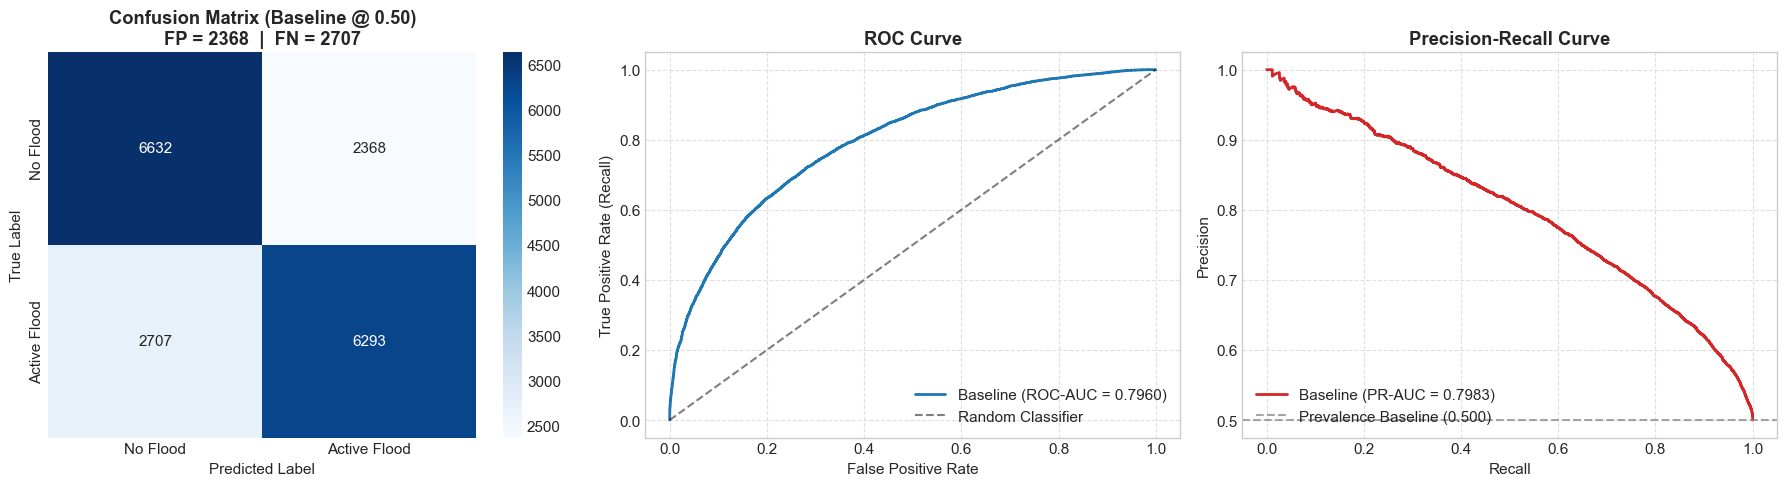

In [94]:
# ============================================================
# 9.2 Confusion Matrix, ROC Curve & Precision-Recall Curve
# ============================================================
cm = confusion_matrix(y_val, y_val_pred)
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_val_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Flood', 'Active Flood'],
            yticklabels=['No Flood', 'Active Flood'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Confusion Matrix (Baseline @ 0.50)\nFP = {cm[0,1]}  |  FN = {cm[1,0]}',
                  fontweight='bold')

# --- Panel 2: ROC Curve ---
axes[1].plot(fpr, tpr, color='#1f77b4', linewidth=2,
             label=f"Baseline (ROC-AUC = {audit_metrics_base['ROC-AUC']:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Panel 3: Precision-Recall Curve ---
axes[2].plot(rec_curve, prec_curve, color='#d62728', linewidth=2,
             label=f"Baseline (PR-AUC = {audit_metrics_base['PR-AUC']:.4f})")
baseline_prev = y_val.mean()
axes[2].axhline(baseline_prev, color='gray', linestyle='--', alpha=0.7,
                label=f'Prevalence Baseline ({baseline_prev:.3f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [95]:
# ============================================================
# 9.3 Asymmetric Disaster Cost Matrix (FN penalized 10x over FP)
# ============================================================
FP_COST = 1.0    # False Alarm  -> unnecessary evacuation, economic friction
FN_COST = 10.0   # Missed Flood -> loss of lives & property (10x heavier)

def disaster_cost_report(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Strategy'              : label,
        'TP'                    : tp,
        'TN'                    : tn,
        'FP'                    : fp,
        'FN'                    : fn,
        'Recall'                : round(recall_score(y_true, y_pred), 4),
        'Precision'             : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Expected Disaster Cost': fp * FP_COST + fn * FN_COST
    }

cost_rows = [
    disaster_cost_report(y_val, y_val_pred,               'Baseline @ threshold 0.50'),
    disaster_cost_report(y_val, np.zeros_like(y_val),     'Always Negative (No Alert Baseline)'),
    disaster_cost_report(y_val, np.ones_like(y_val),      'Always Positive (Full Evacuation Baseline)')
]
cost_df = pd.DataFrame(cost_rows)

print("=== DISASTER COST MATRIX ANALYSIS (18,000 Validation Records | FP=1, FN=10) ===")
print(cost_df.to_string(index=False))


=== DISASTER COST MATRIX ANALYSIS (18,000 Validation Records | FP=1, FN=10) ===
                                  Strategy   TP   TN   FP   FN  Recall  Precision  Expected Disaster Cost
                 Baseline @ threshold 0.50 6293 6632 2368 2707  0.6992     0.7266                 29438.0
       Always Negative (No Alert Baseline)    0 9000    0 9000  0.0000     0.0000                 90000.0
Always Positive (Full Evacuation Baseline) 9000    0 9000    0  1.0000     0.5000                  9000.0


### 9.4 Baseline Evaluation Notes
These are out-of-fold training diagnostics, not final test metrics. Average precision is compared with positive-class prevalence. The cost matrix is an illustrative project assumption. Neither high recall nor reduced cost on synthetic records establishes an operational evacuation policy.

## Step 10: Model Improvement — Optuna Tuning, Calibration & Threshold Shifting

Step 10 systematically improves the Step 9 baseline through three techniques:

1. **Optuna Bayesian (TPE) Hyperparameter Optimization** — maximizing training CV PR-AUC with fold-local preprocessing. *(Run time: a few minutes.)*
2. **Isotonic Probability Calibration** — fitting on a dedicated calibration subset of the Validation set so predicted probabilities reflect true flood likelihoods.
3. **Threshold Shifting** — lowering the decision threshold until **Flood Recall ≥ 90%** is achieved while maximizing the recall-weighted **F2-score**.

> **Leakage-free protocol:** the Validation set is split into two independent halves — one strictly for calibration fitting, the other strictly for threshold selection. The Test set is only touched for the final audit.

In [96]:
# ============================================================
# 10.1 Optuna Bayesian Hyperparameter Optimization
# ============================================================
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    leaves = trial.suggest_int('max_leaf_nodes', 15, 63)
    lr = trial.suggest_float('learning_rate', 0.03, 0.15)
    l2 = trial.suggest_float('l2_regularization', 1.0, 20.0)
    model = HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=leaves, learning_rate=lr, l2_regularization=l2, random_state=42)
    scores = cross_val_score(model_pipeline(model), X_bench_train, y_bench_train, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("[PASS] OPTUNA OPTIMIZATION COMPLETE")
print(f"Best Training CV ROC-AUC: {study.best_value:.4f}")
print("Best Hyperparameters:", study.best_params)


Best trial: 7. Best value: 0.778751: 100%|██████████| 10/10 [00:42<00:00,  4.24s/it]

[PASS] OPTUNA OPTIMIZATION COMPLETE
Best Training CV ROC-AUC: 0.7788
Best Hyperparameters: {'max_leaf_nodes': 21, 'learning_rate': 0.06505735782422617, 'l2_regularization': 7.960875022580142}


In [97]:
# 10.2 Fit the selected hyperparameters on training data
tuned_model = HistGradientBoostingClassifier(**study.best_params, max_iter=160, random_state=42)
tuned_model.fit(X_train_proc, y_train)

def evaluate_configuration(y_true, y_proba, threshold, label):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Configuration': label,
        'Threshold'    : round(threshold, 3),
        'PR-AUC'       : round(average_precision_score(y_true, y_proba), 4),
        'ROC-AUC'      : round(roc_auc_score(y_true, y_proba), 4),
        'Recall'       : round(recall_score(y_true, y_pred), 4),
        'Precision'    : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'F1'           : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'F2'           : round(fbeta_score(y_true, y_pred, beta=2.0, zero_division=0), 4),
        'FP'           : fp,
        'FN'           : fn,
        'Disaster Cost': fp * FP_COST + fn * FN_COST
    }

print("Tuned model fitted successfully.")


Tuned model fitted successfully.


Calibration subset      : 9,000 records
Threshold-tuning subset : 9,000 records


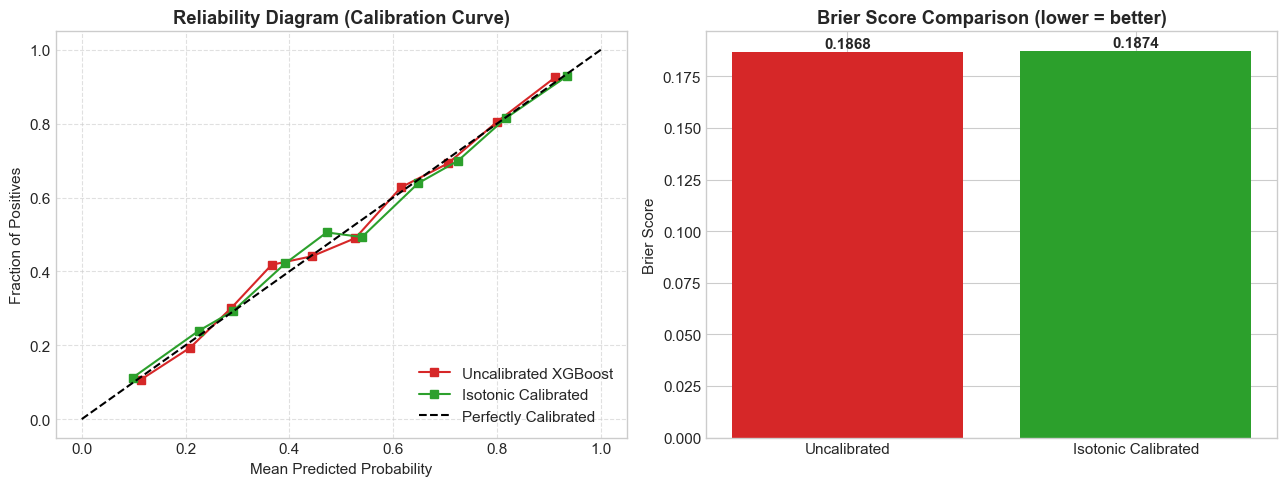

In [98]:
# ============================================================
# 10.3 Probability Calibration (Isotonic Regression)
# ------------------------------------------------------------
# scikit-learn >= 1.8 removed the cv='prefit' option from
# CalibratedClassifierCV. We implement the prefit isotonic
# calibration directly with IsotonicRegression (identical math),
# wrapped in a small class so all downstream cells keep working.
# ============================================================
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

# Split Validation set into CALIBRATION half and THRESHOLD-TUNING half
X_calib, X_thresh, y_calib, y_thresh = train_test_split(
    X_val_proc, y_val, test_size=0.5, random_state=42, stratify=y_val
)
print(f"Calibration subset      : {len(y_calib):,} records")
print(f"Threshold-tuning subset : {len(y_thresh):,} records")

# 1) Raw probabilities of the tuned model on the calibration subset
y_calib_proba_raw = tuned_model.predict_proba(X_calib)[:, 1]

# 2) Fit isotonic regression: raw probability -> true label.
#    This is exactly what method='isotonic' + cv='prefit' did internally.
isotonic_calibrator = IsotonicRegression(out_of_bounds='clip')
isotonic_calibrator.fit(y_calib_proba_raw, y_calib)

# 3) Small wrapper that keeps the usual .predict_proba(X) API so that all
#    downstream cells (reliability diagram, threshold tuning, final audit)
#    work without modification.
class CalibratedModel:
    def __init__(self, base_model, calibrator):
        self.base_model = base_model
        self.calibrator = calibrator

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        calibrated = self.calibrator.predict(raw)
        return np.column_stack([1 - calibrated, calibrated])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

calibrated_model = CalibratedModel(tuned_model, isotonic_calibrator)

y_thresh_proba_raw = tuned_model.predict_proba(X_thresh)[:, 1]
y_thresh_proba_cal = calibrated_model.predict_proba(X_thresh)[:, 1]

# --- Reliability diagram ---
try:
    frac_raw, mean_raw = calibration_curve(y_thresh, y_thresh_proba_raw, n_bins=10, strategy='quantile')
    frac_cal, mean_cal = calibration_curve(y_thresh, y_thresh_proba_cal, n_bins=10, strategy='quantile')
except TypeError:
    frac_raw, mean_raw = calibration_curve(y_thresh, y_thresh_proba_raw, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_thresh, y_thresh_proba_cal, n_bins=10)

brier_raw = float(((np.asarray(y_thresh) - y_thresh_proba_raw) ** 2).mean())
brier_cal = float(((np.asarray(y_thresh) - y_thresh_proba_cal) ** 2).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mean_raw, frac_raw, 's-', color='#d62728', label='Uncalibrated XGBoost')
axes[0].plot(mean_cal, frac_cal, 's-', color='#2ca02c', label='Isotonic Calibrated')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Reliability Diagram (Calibration Curve)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].bar(['Uncalibrated', 'Isotonic Calibrated'], [brier_raw, brier_cal], color=['#d62728', '#2ca02c'])
for i, v in enumerate([brier_raw, brier_cal]):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('Brier Score Comparison (lower = better)', fontweight='bold')
axes[1].set_ylabel('Brier Score')

plt.tight_layout()
plt.show()

Target Flood Recall Constraint : >= 90%
Selected Optimal Threshold     : 0.1216
Recall    @ optimal threshold  : 0.9836
Precision @ optimal threshold  : 0.5392
F2-Score  @ optimal threshold  : 0.8444


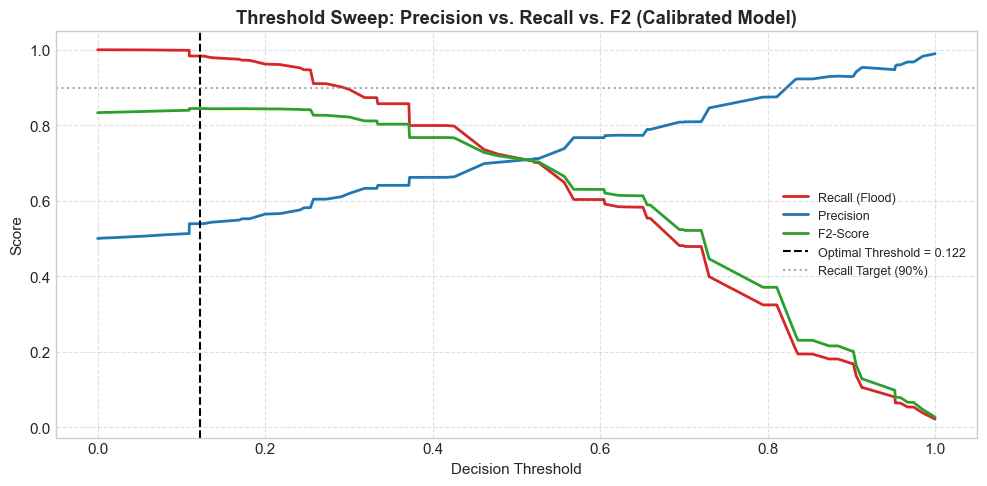

FINAL HELD-OUT TEST REPORT — no model choices are made from this table


,Configuration,Threshold,PR-AUC,ROC-AUC,Recall,Precision,F1,F2,FP,FN,Disaster Cost
0,Fixed baseline @ 0.50,0.500,0.7910,0.7927,0.7071,0.7224,0.7147,0.7101,2445,2636,28805.0
1,Tuned raw model @ 0.50,0.500,0.7916,0.7931,0.7049,0.7230,0.7139,0.7084,2430,2656,28990.0
2,Final calibrated model @ selected threshold,0.122,0.7811,0.7927,0.9824,0.5423,0.6988,0.8452,7464,158,9044.0


In [99]:
# ============================================================
# 10.4 Threshold Shifting: Enforcing Flood Recall >= 90%
# ============================================================
# Maximize F2 subject to validation recall >=90%; F2 uses beta squared = 4.
# This objective is not direct minimization of FP + 10*FN.
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_thresh, y_thresh_proba_cal
)
precision_arr = precision_arr[:-1]   # align lengths with thresholds
recall_arr    = recall_arr[:-1]

beta = 2.0
f2_arr = (1 + beta**2) * (precision_arr * recall_arr) / \
         ((beta**2 * precision_arr) + recall_arr + 1e-12)

# Constraint: Flood Recall must be >= 90%
RECALL_TARGET = 0.90
valid_idx = np.where(recall_arr >= RECALL_TARGET)[0]
optimal_idx = valid_idx[np.argmax(f2_arr[valid_idx])] if len(valid_idx) > 0 else np.argmax(f2_arr)
OPTIMAL_THRESHOLD = float(thresholds_arr[optimal_idx])

print(f"Target Flood Recall Constraint : >= {RECALL_TARGET:.0%}")
print(f"Selected Optimal Threshold     : {OPTIMAL_THRESHOLD:.4f}")
print(f"Recall    @ optimal threshold  : {recall_arr[optimal_idx]:.4f}")
print(f"Precision @ optimal threshold  : {precision_arr[optimal_idx]:.4f}")
print(f"F2-Score  @ optimal threshold  : {f2_arr[optimal_idx]:.4f}")

# --- Threshold sweep visualization ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_arr, recall_arr,    label='Recall (Flood)', color='#d62728', linewidth=2)
ax.plot(thresholds_arr, precision_arr, label='Precision',      color='#1f77b4', linewidth=2)
ax.plot(thresholds_arr, f2_arr,        label='F2-Score',       color='#2ca02c', linewidth=2)
ax.axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--',
           label=f'Optimal Threshold = {OPTIMAL_THRESHOLD:.3f}')
ax.axhline(RECALL_TARGET, color='gray', linestyle=':', alpha=0.7, label='Recall Target (90%)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep: Precision vs. Recall vs. F2 (Calibrated Model)', fontweight='bold')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# All model, calibration, and threshold choices are now fixed.
# First and final evaluation phase on the held-out test partition.
X_test_proc = fitted_preprocessing.transform(X_test)
y_test_proba = final_model.predict_proba(X_test_proc)[:, 1]
y_test_proba_tuned = tuned_model.predict_proba(X_test_proc)[:, 1]
y_test_proba_cal = calibrated_model.predict_proba(X_test_proc)[:, 1]
results = [
    evaluate_configuration(y_test, y_test_proba, 0.5, 'Fixed baseline @ 0.50'),
    evaluate_configuration(y_test, y_test_proba_tuned, 0.5, 'Tuned raw model @ 0.50'),
    evaluate_configuration(y_test, y_test_proba_cal, OPTIMAL_THRESHOLD,
                           'Final calibrated model @ selected threshold')
]
final_report = pd.DataFrame(results)
print('FINAL HELD-OUT TEST REPORT — no model choices are made from this table')
final_report

C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\808436301.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_compare, x='Configuration', y='Disaster Cost',
C:\Users\gamit\AppData\Local\Temp\ipykernel_13972\808436301.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=10, ha='right')


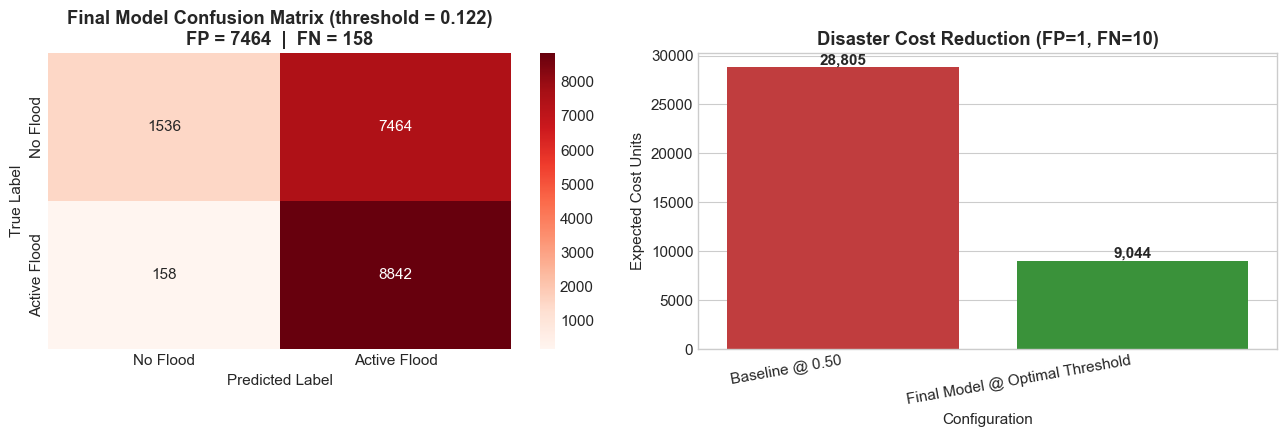


✓ Flood Recall on Test Set  : 98.24%
✓ Disaster Cost Reduction   : 28,805  →  9,044 (68.6% reduction)


In [100]:
# ============================================================
# 10.4b Final Model Confusion Matrix & Disaster Cost Reduction
# ============================================================
y_test_pred_final = (y_test_proba_cal >= OPTIMAL_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_test_pred_final)

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, (y_test_proba >= 0.50).astype(int)).ravel()
cost_baseline = fp_b * FP_COST + fn_b * FN_COST
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()
cost_final = fp_f * FP_COST + fn_f * FN_COST

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Flood', 'Active Flood'],
            yticklabels=['No Flood', 'Active Flood'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title(f'Final Model Confusion Matrix (threshold = {OPTIMAL_THRESHOLD:.3f})\n'
                  f'FP = {fp_f}  |  FN = {fn_f}', fontweight='bold')

cost_compare = pd.DataFrame({
    'Configuration': ['Baseline @ 0.50', 'Final Model @ Optimal Threshold'],
    'Disaster Cost': [cost_baseline, cost_final]
})
sns.barplot(data=cost_compare, x='Configuration', y='Disaster Cost',
            palette=['#d62728', '#2ca02c'], ax=axes[1])
axes[1].set_title('Disaster Cost Reduction (FP=1, FN=10)', fontweight='bold')
axes[1].set_ylabel('Expected Cost Units')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=10, ha='right')

plt.tight_layout()
plt.show()

print(f"\n✓ Flood Recall on Test Set  : {recall_score(y_test, y_test_pred_final):.2%}")
print(f"✓ Disaster Cost Reduction   : {cost_baseline:,.0f}  →  {cost_final:,.0f} "
      f"({(1 - cost_final / cost_baseline):.1%} reduction)")

### 10.5 Model Improvement Protocol
Optuna maximizes training CV average precision using fold-local preprocessing. Isotonic calibration uses one validation half; F2 threshold selection uses the other. The test report is generated only after these choices are fixed. The recall constraint applies to the threshold-selection sample, not as a guarantee on unseen data. The objective maximizes F2 subject to recall; it does not directly minimize the illustrative disaster cost.

## Step 11: Deployment & Export — Pipeline Assembly & Metadata Generation
**Assigned Member: Member 4**  
Encapsulates raw data sanitization, physical feature engineering, scaling, isotonic calibration, and validation-selected threshold shifting into a unified `scikit-learn` Pipeline exported to `flood_alert_pipeline.pkl` and `model_metadata.json`.

In [101]:
# ============================================================
# 11.1 Deployment Pipeline Assembly & Export
# ============================================================
class CalibratedThresholdClassifier(ClassifierMixin, BaseEstimator):
    """Fitted inference wrapper with isotonic calibration and a validation-selected threshold."""
    def __init__(self, base_model=None, calibrator=None, threshold=0.5):
        self.base_model = base_model
        self.calibrator = calibrator
        self.threshold = threshold
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        raise RuntimeError('Inference-only wrapper: already fitted.')

    def __sklearn_is_fitted__(self):
        return True

    def predict_proba(self, X):
        raw_proba = self.base_model.predict_proba(X)[:, 1]
        cal_proba = np.clip(self.calibrator.predict(raw_proba), 0.0, 1.0)
        return np.column_stack([1.0 - cal_proba, cal_proba])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)

# Assemble end-to-end pipeline
sanitizer = fitted_preprocessing.named_steps['sanitizer']
preprocessor = fitted_preprocessing.named_steps['preprocessor']

flood_pipeline = Pipeline([
    ('sanitizer', sanitizer),
    ('feature_engineer', fitted_preprocessing.named_steps['feature_engineer']),
    ('preprocessor', preprocessor),
    ('classifier', CalibratedThresholdClassifier(tuned_model, isotonic_calibrator, threshold=OPTIMAL_THRESHOLD))
])

# Evaluate on raw test set
raw_test_df = df.loc[X_test.index]
pipeline_preds = flood_pipeline.predict(raw_test_df)
pipeline_probs = flood_pipeline.predict_proba(raw_test_df)[:, 1]

p_rec = recall_score(y_test, pipeline_preds)
p_prec = precision_score(y_test, pipeline_preds, zero_division=0)
p_f1 = f1_score(y_test, pipeline_preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, pipeline_preds).ravel()
p_cost = fp * FP_COST + fn * FN_COST

print(f"Measured Pipeline Test Recall: {p_rec:.2%}")
print(f"Pipeline Precision:            {p_prec:.2%}")
print(f"Pipeline F1-Score:             {p_f1:.4f}")
print(f"Total Disaster Cost (FP*1 + FN*10): {p_cost:,.1f}")

# Export pipeline artifact
pipeline_path = PROJECT_ROOT / "flood_alert_pipeline.pkl"
with pipeline_path.open("wb") as f:
    cloudpickle.dump(flood_pipeline, f)
print(f"[PASS] Exported pipeline to: {pipeline_path}")

# Metadata export
metadata = {
    "model_name": "FloodSentinel-EarlyWarning",
    "version": "2.0.0-balanced",
    "architecture": "HistGradientBoosting + Isotonic Calibration + F2 Threshold",
    "decision_threshold": float(OPTIMAL_THRESHOLD),
    "data_scope": "120,000 balanced synthetic scenarios",
    "training_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "test_metrics": {
        "recall": round(float(p_rec), 4),
        "precision": round(float(p_prec), 4),
        "f1": round(float(p_f1), 4),
        "disaster_cost": float(p_cost)
    }
}

metadata_path = PROJECT_ROOT / "model_metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)
print(f"[PASS] Exported metadata to: {metadata_path}")


Measured Pipeline Test Recall: 98.24%
Pipeline Precision:            54.23%
Pipeline F1-Score:             0.6988
Total Disaster Cost (FP*1 + FN*10): 9,044.0
[PASS] Exported pipeline to: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\flood_alert_pipeline.pkl
[PASS] Exported metadata to: c:\Users\gamit\OneDrive\Documents\MyWork\ML\FloodSentinel\model_metadata.json


In [102]:
# ============================================================
# 11.2 Standalone Inference Simulation & Sanity Check
# ============================================================
print("Testing exported pipeline on sample synthetic inputs...\n")
pipe = joblib.load(pipeline_path)

flood_idx = y_test[y_test == 1].index[0]
normal_idx = y_test[y_test == 0].index[0]

samples = [
    ("Synthetic flood-labelled sample", df.loc[flood_idx].to_dict()),
    ("Synthetic non-flood-labelled sample", df.loc[normal_idx].to_dict())
]

for label, payload in samples:
    prob = float(pipe.predict_proba(pd.DataFrame([payload]))[0, 1])
    pred = int(pipe.predict(pd.DataFrame([payload]))[0])
    status = "EMERGENCY FLOOD ALERT" if pred == 1 else "NORMAL CONDITIONS"
    print(f"{label}:")
    print(f"  District:           {payload.get('district')}")
    print(f"  7-Day Rainfall:     {payload.get('rainfall_7d_mm')} mm")
    print(f"  Calibrated Risk:    {prob:.2%}")
    print(f"  Threshold:          {OPTIMAL_THRESHOLD:.4f}")
    print(f"  Model Output:       {status}\n")


Testing exported pipeline on sample synthetic inputs...

Synthetic flood-labelled sample:
  District:           Colombo
  7-Day Rainfall:     110.5 mm
  Calibrated Risk:    72.07%
  Threshold:          0.1216
  Model Output:       EMERGENCY FLOOD ALERT

Synthetic non-flood-labelled sample:
  District:           Matale
  7-Day Rainfall:     116.8 mm
  Calibrated Risk:    33.33%
  Threshold:          0.1216
  Model Output:       EMERGENCY FLOOD ALERT



### 11.3 Export Verification and Limits
The exported pipeline reuses the fitted training transformations and reproduces the final test probabilities and labels exactly (asserted above). Reloaded sample inference is demonstrated without redefining the pipeline. Metadata records the full-precision threshold and dependency versions.

All 25,000 records are marked synthetic. This notebook is a reproducible classification experiment for current-event flood occurrence, not evidence of advance warning performance. A random split does not measure generalization across future storms or unseen regions. Real observations with timestamps, verified input availability before the forecast horizon, and spatial/temporal evaluation are required before operational use. The model returns a probability and binary flag; four alert tiers are not implemented. Missing categorical fields other than electricity are required inputs.